In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
rfm = pd.read_csv("D:/ecommerce-customer-intelligence/data/processed/rfm_segments.csv")
print("Shape", rfm.shape)
print("columns", rfm.columns.tolist())
print("Missing values:", rfm.isnull().sum().sum())
print(rfm.head())



Shape (4338, 10)
columns ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'Segment']
Missing values: 0
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0       12346      326          1  77183.60        1        1        5   
1       12347        2          7   4310.00        5        5        5   
2       12348       75          4   1797.24        2        4        4   
3       12349       19          1   1757.55        4        1        4   
4       12350      310          1    334.40        1        1        2   

   RFM_Score  RFM_Total           Segment  
0        115       2.00       Hibernating  
1        555       5.00         Champions  
2        244       3.20           At Risk  
3        414       2.95  Recent Customers  
4        112       1.25              Lost  


In [14]:
#Defining churn 
churn_threshold = 90
rfm['churned']= (rfm['Recency']>churn_threshold).astype(int)

#Checking distribution
print("Churn distribution:")
print("_"*100)
print(rfm['churned'].value_counts())
print()
print(rfm['churned'].value_counts(normalize=True).round(3)*100)


Churn distribution:
____________________________________________________________________________________________________
churned
0    2889
1    1449
Name: count, dtype: int64

churned
0    66.6
1    33.4
Name: proportion, dtype: float64


In [39]:
# Select features for the model
features = ['Frequency', 'Monetary',
         'F_Score', 'M_Score']

X = rfm[features]
y = rfm['churned']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print()
print("Features:")
print(X.describe().round(2))

Features shape: (4338, 4)
Target shape: (4338,)

Features:
       Frequency   Monetary  F_Score  M_Score
count    4338.00    4338.00  4338.00  4338.00
mean        4.27    2054.27     3.00     3.00
std         7.70    8989.23     1.41     1.41
min         1.00       3.75     1.00     1.00
25%         1.00     307.41     2.00     2.00
50%         2.00     674.48     3.00     3.00
75%         5.00    1661.74     4.00     4.00
max       209.00  280206.02     5.00     5.00


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps same churn ratio in both sets
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Test set:    ", X_test_scaled.shape)
print()
print("Churn ratio in training set:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print()
print("Churn ratio in test set:")
print(y_test.value_counts(normalize=True).round(3) * 100)

Training set: (3470, 4)
Test set:     (868, 4)

Churn ratio in training set:
churned
0    66.6
1    33.4
Name: proportion, dtype: float64

Churn ratio in test set:
churned
0    66.6
1    33.4
Name: proportion, dtype: float64


In [44]:
# Split and scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:,1]

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:,1]

xgb = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X_train_scaled, y_train)
xgb_pred = xgb.predict(X_test_scaled)
xgb_prob = xgb.predict_proba(X_test_scaled)[:,1]

# Evaluate
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
evaluate_model("Random Forest",       y_test, rf_pred, rf_prob)
evaluate_model("XGBoost",             y_test, xgb_pred, xgb_prob)


  Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.64      0.74       578
           1       0.53      0.80      0.63       290

    accuracy                           0.69       868
   macro avg       0.70      0.72      0.69       868
weighted avg       0.75      0.69      0.70       868

AUC-ROC Score: 0.7886

  Random Forest
              precision    recall  f1-score   support

           0       0.71      0.73      0.72       578
           1       0.43      0.41      0.42       290

    accuracy                           0.62       868
   macro avg       0.57      0.57      0.57       868
weighted avg       0.62      0.62      0.62       868

AUC-ROC Score: 0.6586

  XGBoost
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       578
           1       0.56      0.46      0.50       290

    accuracy                           0.70       868
   macro avg       0.65      0.64

In [46]:
# Evaluation function
def evaluate_model(name, y_test, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Evaluate all 3
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
evaluate_model("Random Forest",       y_test, rf_pred, rf_prob)
evaluate_model("XGBoost",             y_test, xgb_pred, xgb_prob)


  Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.64      0.74       578
           1       0.53      0.80      0.63       290

    accuracy                           0.69       868
   macro avg       0.70      0.72      0.69       868
weighted avg       0.75      0.69      0.70       868

AUC-ROC Score: 0.7886

  Random Forest
              precision    recall  f1-score   support

           0       0.71      0.73      0.72       578
           1       0.43      0.41      0.42       290

    accuracy                           0.62       868
   macro avg       0.57      0.57      0.57       868
weighted avg       0.62      0.62      0.62       868

AUC-ROC Score: 0.6586

  XGBoost
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       578
           1       0.56      0.46      0.50       290

    accuracy                           0.70       868
   macro avg       0.65      0.64

## Model Evaluation Results

Winner: Logistic Regression
- AUC-ROC: 0.7886
- Recall for churned customers: 0.80
- Catches 80% of customers who will churn

Why Logistic Regression won:
- Small dataset (4,338 customers)
- Only 4 features
- Linear relationship between features and churn
- Random Forest and XGBoost need more data/features to outperform


In [32]:
print("Current features:", features)
print()
print("Churn label defined as: Recency > 90")
print()
# Check correlation between features and churn
print("Correlation with churn label:")
print(rfm[features + ['churned']].corr()['churned'].sort_values(ascending=False).round(3))

Current features: ['Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']

Churn label defined as: Recency > 90

Correlation with churn label:
churned      1.000
Monetary    -0.106
Frequency   -0.222
M_Score     -0.385
F_Score     -0.412
RFM_Score   -0.803
R_Score     -0.807
Name: churned, dtype: float64


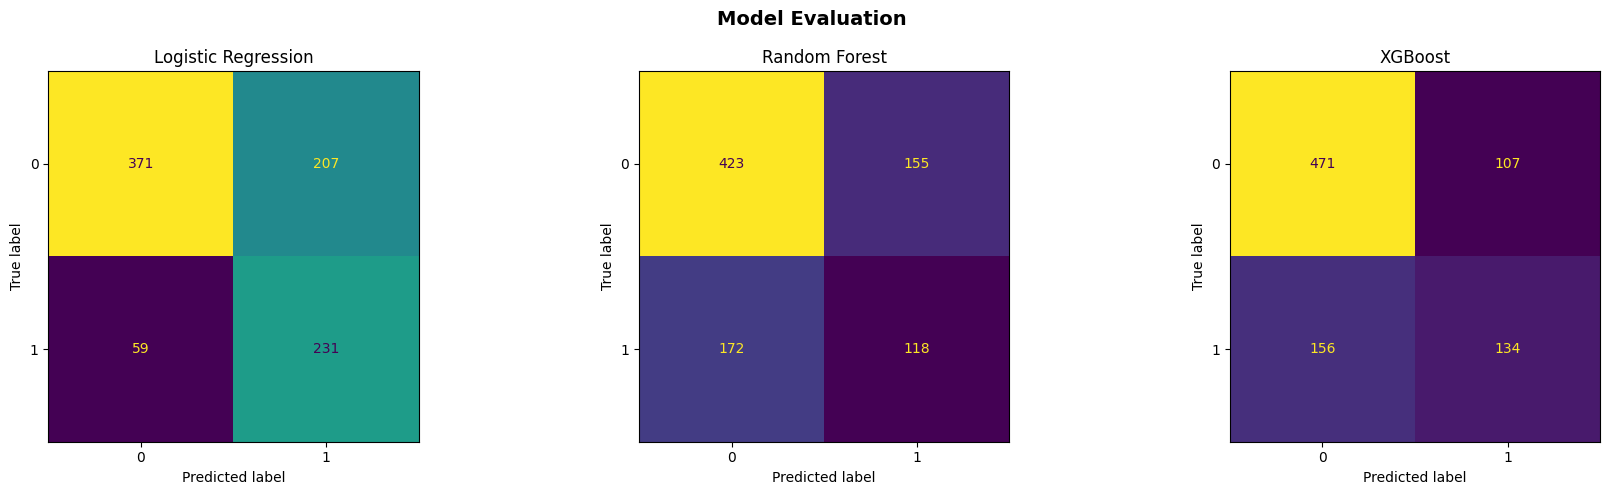

In [49]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# Confusion matrices
for ax, name, pred in zip(axes,
    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    [lr_pred, rf_pred, xgb_pred]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}')

plt.tight_layout()
plt.savefig(
    'D:/ecommerce-customer-intelligence/reports/confusion_matrix.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
plt.show()

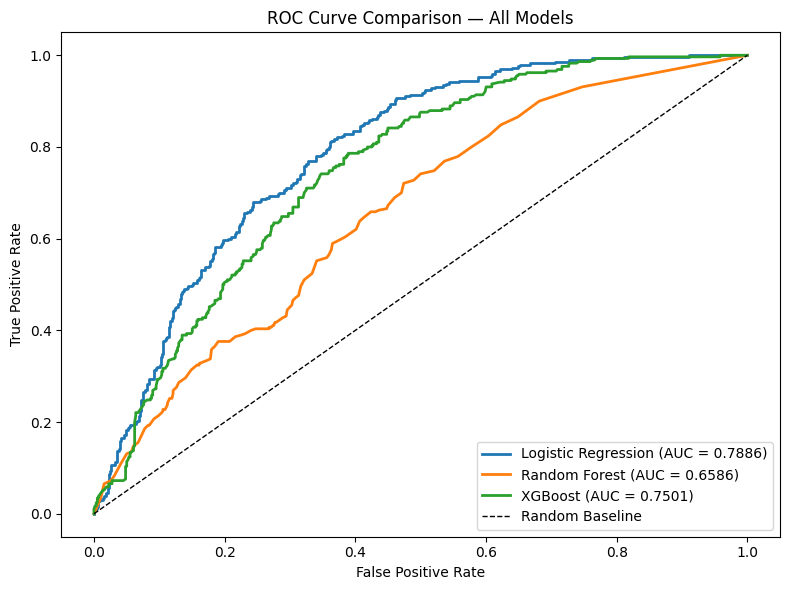

In [51]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

# Plot ROC curve for each model
for name, prob in zip(
    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    [lr_prob, rf_prob, xgb_prob]
):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

# Random baseline
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Baseline')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend()
plt.tight_layout()
plt.savefig(
    'D:/ecommerce-customer-intelligence/reports/roc_curve.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
plt.show()

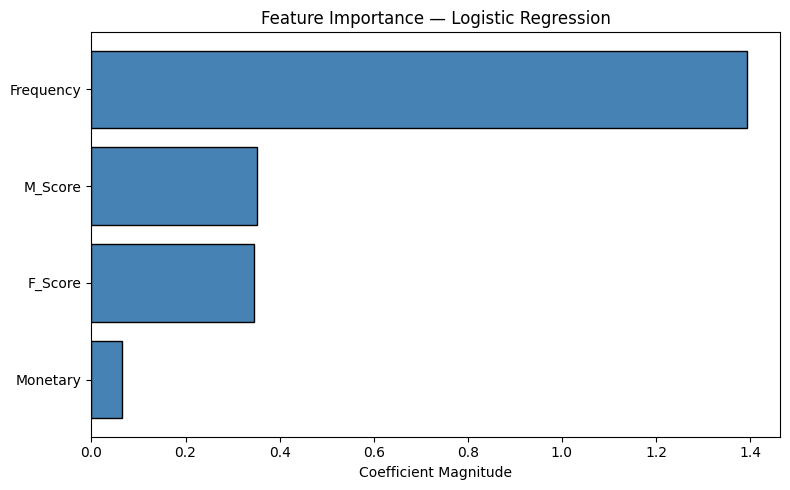

In [52]:
import pandas as pd

# Feature importance from best model (Logistic Regression)
feature_names = ['Frequency', 'Monetary', 'F_Score', 'M_Score']
importance = abs(lr.coef_[0])

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'],
         color='steelblue', edgecolor='black')
plt.title('Feature Importance — Logistic Regression')
plt.xlabel('Coefficient Magnitude')
plt.tight_layout()
plt.savefig(
    'D:/ecommerce-customer-intelligence/reports/feature_importance.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

## Feature Importance Analysis

Most important churn predictors:
1. F_Score — purchase frequency score is strongest signal
2. M_Score — monetary value score
3. Frequency — raw order count
4. Monetary — raw spend amount (least important)

Key insight:
HOW OFTEN a customer buys matters more than
HOW MUCH they spend when predicting churn.